In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



#Observation
The dataset contains 1000 retail transactions.
It includes customer details such as Age and Gender, along with purchase information like Product Category, Quantity, Price per Unit, and Total Amount.
The data is suitable for sales analysis.
#Business Recommendation
Since the dataset is complete, it can be used for customer behavior analysis and sales forecasting.

In [4]:
import pandas as pd

df = pd.read_csv('/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
import os

for root, dirs, files in os.walk('/retail_sales_dataset.csv'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

In [9]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [11]:
len(df)

1000

In [13]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']



#Observation

If df.isnull().sum() shows 0 for all columns:

There are no missing values in the dataset, indicating that the data is complete and ready for analysis.

#Business Recommendation
Continue maintaining high data quality by validating data during collection.

In [15]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [17]:
# Statistical Summary
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632



#Observation

If df.duplicated().sum() is 0:

No duplicate records were found, ensuring accurate analysis.

#Business Recommendation
Regularly check for duplicate transactions to maintain data accuracy.

In [19]:
# Missing Values
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [21]:
df.duplicated().sum()

np.int64(0)

## Observation
- Male and Female customers contribute almost equally to the total transactions.

## Business Recommendation
- Design marketing campaigns that target both male and female customers effectively.

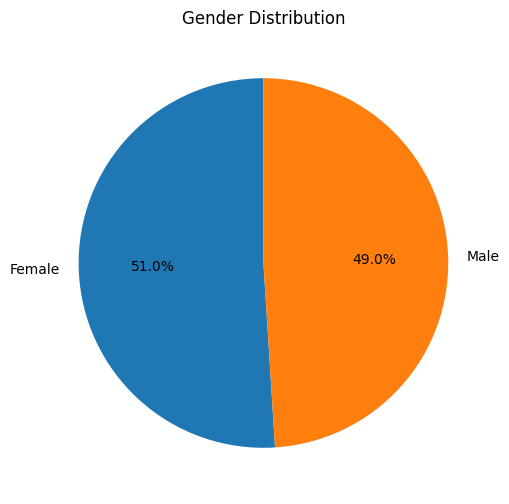

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

## Observation
- Electronics and Clothing are among the most purchased product categories.

## Business Recommendation
- Maintain higher inventory for high-demand products and promote low-selling categories.

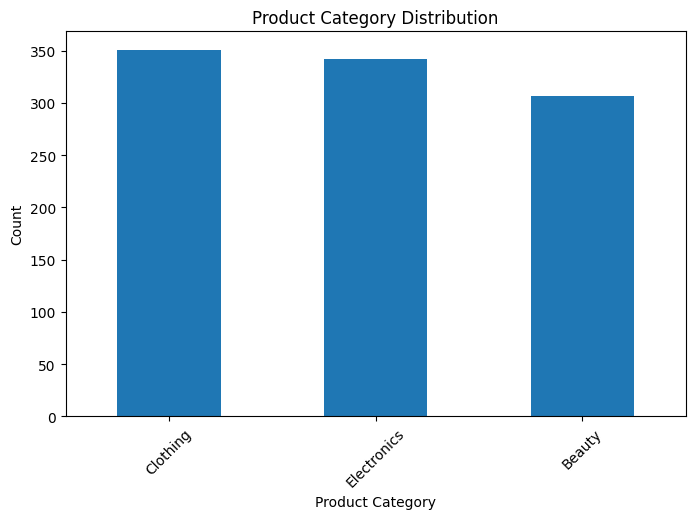

In [25]:
plt.figure(figsize=(8,5))
df['Product Category'].value_counts().plot(kind='bar')

plt.title("Product Category Distribution")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

#Observation

Example:

Electronics generated the highest total sales among all product categories.

#Business Recommendation
Focus marketing and inventory planning on high-revenue categories.
Review pricing or promotional strategies for lower-performing categories.

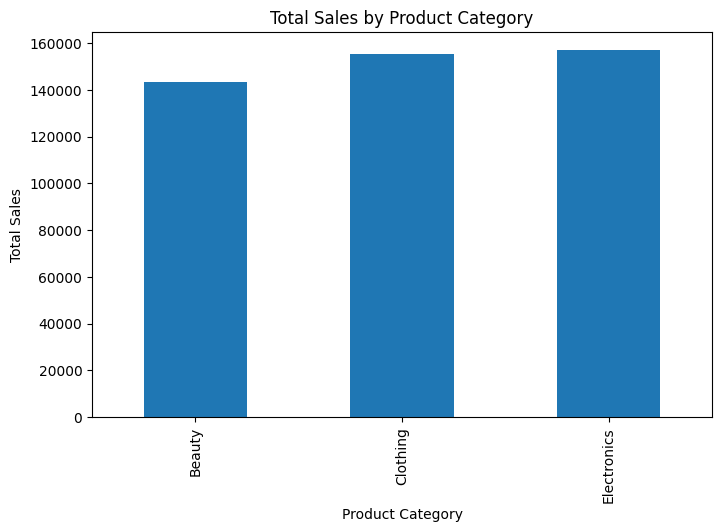

In [27]:
sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))
sales.plot(kind='bar')

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()

#Observation

Example:

Sales increased during some months and decreased during others, indicating seasonal buying patterns.

#Business Recommendation
Launch special offers during low-sales months.
Increase inventory and staffing before high-sales periods.

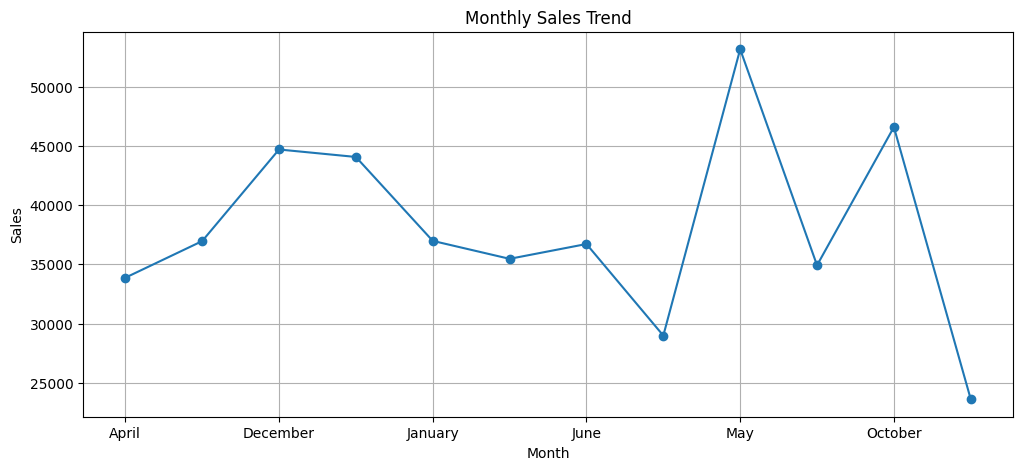

In [29]:
df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

#Observation

Example:

Most customers are between 25 and 45 years old.

#Business Recommendation
Create marketing campaigns aimed at this age group.
Introduce products that match their interests and needs.

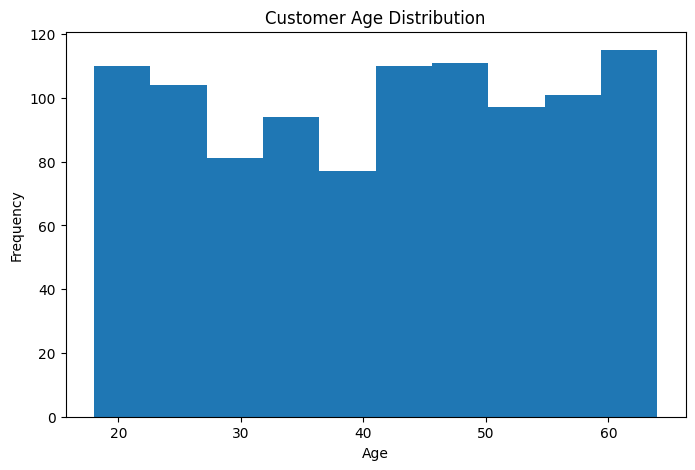

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

#Observation

Example:

Quantity and Total Amount show a positive correlation, meaning that buying more items generally increases the total bill.

#Business Recommendation
Encourage bulk purchases through discounts or bundle offers.

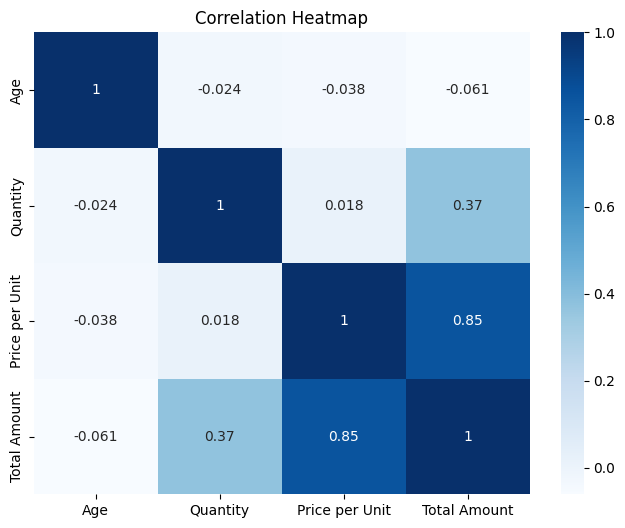

In [31]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Age','Quantity','Price per Unit','Total Amount']].corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

The exploratory data analysis revealed valuable insights into customer demographics, product performance, and sales trends. The dataset is clean and suitable for analysis. The findings can help businesses improve inventory management, optimize marketing strategies, and make better data-driven decisions.
